# MAMMAL Model Inference Notebook

Run inference with a finetuned MAMMAL model on **any CSV file** containing SMILES strings.

**Fully self-contained** — no `ligand_ai` package import, no subprocess, no Hydra, no train/val files needed.

## Steps
0. Configuration (edit paths here)
1. Preview input data
2. Load tokenizer
3. Load model
4. Build DataLoader (inline — no train/val needed)
5. Run inference (inline predict loop)
6. Inspect predictions
7. Evaluate (if labels available)
8. Top hits
9. Save hits above threshold

## 0. Configuration

**Edit the three paths below before running.**

In [8]:
import os

# ── USER SETTINGS ─────────────────────────────────────────────────────────────

# Path to the finetuned Lightning checkpoint (.ckpt)
MODEL_PATH = "/proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal/last.ckpt"

# Path to a CSV/TSV file with SMILES (and optionally labels)
DATA_PATH = "/proj/ligand_ai/datasets_manager/processed/splits/wdr91_ASMS_train_val_v1/test.csv"

# Where to write the predictions CSV
OUTPUT_PATH = "/proj/ligand_ai/results/wdr91_ASMS_train_val_v1/mammal_notebook_predictions.csv"

# Column names in the input CSV
SMILES_COLUMN = "smiles"
LABEL_COLUMN  = "label"   # set to None if the file has no labels

# Target / assay (must match training)
TARGET_NAME = "WDR91"
ASSAY_TYPE  = "ASMS"

# Special tokens added during training
NEW_SPECIAL_TOKENS = ["<PGK2_ASMS>", "<WDR91_ASMS>"]

# Base MAMMAL tokenizer / model (HuggingFace hub id or local path)
BASE_MODEL_PATH = "ibm/biomed.omics.bl.sm.ma-ted-458m"

# Inference device
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# DataLoader settings
BATCH_SIZE             = 128
DRUG_MAX_SEQ_LENGTH    = 300
ENCODER_INPUT_MAX_LEN  = 320
LABELS_MAX_LEN         = 10
NUM_WORKERS            = 0

# ── VALIDATION ────────────────────────────────────────────────────────────────
assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.exists(DATA_PATH),  f"Data not found:  {DATA_PATH}"
os.makedirs(os.path.dirname(OUTPUT_PATH) or ".", exist_ok=True)

print(f"Model : {MODEL_PATH}")
print(f"Data  : {DATA_PATH}")
print(f"Output: {OUTPUT_PATH}")
print(f"Device: {DEVICE}")

Model : /proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal/last.ckpt
Data  : /proj/ligand_ai/datasets_manager/processed/splits/wdr91_ASMS_train_val_v1/test.csv
Output: /proj/ligand_ai/results/wdr91_ASMS_train_val_v1/mammal_notebook_predictions.csv
Device: cpu


## 1. Preview Input Data

In [9]:
import pandas as pd

sep = "\t" if DATA_PATH.endswith(".tsv") else ","
input_df = pd.read_csv(DATA_PATH, sep=sep)

print(f"Shape  : {input_df.shape}")
print(f"Columns: {list(input_df.columns)}")

if LABEL_COLUMN and LABEL_COLUMN in input_df.columns:
    print(f"\nLabel distribution:")
    print(input_df[LABEL_COLUMN].value_counts().sort_index())

input_df.head()

Shape  : (234, 2)
Columns: ['smiles', 'label']

Label distribution:
label
0    176
1     58
Name: count, dtype: int64


,smiles,label
0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1
1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1
2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1
3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1
4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1


## 2. Load Tokenizer

In [10]:
from fuse.data.tokenizers.modular_tokenizer.op import ModularTokenizerOp

print(f"Loading tokenizer from: {BASE_MODEL_PATH}")
tokenizer_op = ModularTokenizerOp.from_pretrained(BASE_MODEL_PATH)

if NEW_SPECIAL_TOKENS:
    num_added = tokenizer_op.add_new_special_tokens(NEW_SPECIAL_TOKENS)
    if num_added:
        print(f"Added {num_added} special tokens: {NEW_SPECIAL_TOKENS}")
    else:
        print(f"Special tokens already present: {NEW_SPECIAL_TOKENS}")

print("Tokenizer ready.")

Loading tokenizer from: ibm/biomed.omics.bl.sm.ma-ted-458m


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/u/ella/miniconda/envs/ligand-ai/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


The OrderedVocab you are attempting to save contains holes for indices [314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499

## 3. Load Model

In [11]:
from mammal.model import Mammal

print(f"Loading base MAMMAL from: {BASE_MODEL_PATH}")
model = Mammal.from_pretrained(BASE_MODEL_PATH)

if MODEL_PATH.endswith(".ckpt"):
    print(f"Applying finetuned weights from checkpoint: {MODEL_PATH}")
    checkpoint = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)

    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
        sample_key = list(state_dict.keys())[0]
        print(f"  Sample checkpoint key: {sample_key}")

        # Strip Lightning wrapper prefix (_model. or model.)
        new_state_dict = {}
        for key, value in state_dict.items():
            if key.startswith("_model."):
                new_key = key[7:]
            elif key.startswith("model."):
                new_key = key[6:]
            else:
                new_key = key
            new_state_dict[new_key] = value

        print(f"  Stripped prefix. New sample key: {list(new_state_dict.keys())[0]}")
        missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
        print(f"  Missing keys   : {len(missing)}")
        print(f"  Unexpected keys: {len(unexpected)}")
        if missing:
            print(f"  First missing  : {missing[:5]}")
    else:
        print("  WARNING: No state_dict in checkpoint — using base model weights only.")
else:
    print(f"Loading model directory: {MODEL_PATH}")
    model = Mammal.from_pretrained(MODEL_PATH)

model.eval()
model = model.to(DEVICE)
print(f"\nModel ready on {DEVICE}.")

Loading base MAMMAL from: ibm/biomed.omics.bl.sm.ma-ted-458m
Path doesn't exist. Will try to download from hf hub. pretrained_model_name_or_path='ibm/biomed.omics.bl.sm.ma-ted-458m'


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Attempting to load model from dir: pretrained_model_name_or_path='/u/ella/.cache/huggingface/hub/models--ibm--biomed.omics.bl.sm.ma-ted-458m/snapshots/6d319d8dcf97f8821635327fc8cda24670553daa'
Applying finetuned weights from checkpoint: /proj/ligand_ai/models/wdr91_ASMS_train_val_v1/mammal/last.ckpt
  Sample checkpoint key: _model.t5_model.shared.weight
  Stripped prefix. New sample key: t5_model.shared.weight
  Missing keys   : 0
  Unexpected keys: 0

Model ready on cpu.


## 4. Build DataLoader

All preprocessing code is inlined here — no `ligand_ai` import needed, no train/val files required.

In [12]:
from functools import partial
from torch.utils.data import Dataset, DataLoader
from fuse.data.utils.collates import CollateDefault
from mammal.keys import (
    CLS_PRED, SCORES,
    ENCODER_INPUTS_STR, ENCODER_INPUTS_TOKENS, ENCODER_INPUTS_ATTENTION_MASK,
    LABELS_STR, LABELS_TOKENS, LABELS_ATTENTION_MASK,
    DECODER_INPUTS_STR, DECODER_INPUTS_TOKENS, DECODER_INPUTS_ATTENTION_MASK,
)

# ── Inline dataset ─────────────────────────────────────────────────────────────
class InferenceDataset(Dataset):
    """
    Simple dataset for inference from a single CSV/TSV file.
    No train/val files needed.
    """
    def __init__(self, df, smiles_column, label_column, tokenizer_op,
                 target_name, assay_type,
                 drug_max_seq_length, encoder_input_max_seq_len, labels_max_seq_len):
        self.smiles = df[smiles_column].tolist()
        self.has_labels = label_column is not None and label_column in df.columns
        self.labels = df[label_column].tolist() if self.has_labels else [None] * len(df)
        self.indices = df.index.tolist()
        self.tokenizer_op = tokenizer_op
        self.target_name = target_name.upper()
        self.assay_type = assay_type.upper()
        self.drug_max_seq_length = drug_max_seq_length
        self.encoder_input_max_seq_len = encoder_input_max_seq_len
        self.labels_max_seq_len = labels_max_seq_len
        print(f"InferenceDataset: {len(self.smiles)} samples, has_labels={self.has_labels}")

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        drug_sequence = self.smiles[idx]
        label = self.labels[idx]
        task_identifier = f"{self.target_name}_{self.assay_type}"

        sample = {
            "index": self.indices[idx],
            "data.smiles": drug_sequence,
            "data.label": label,
        }

        # Encoder input
        sample[ENCODER_INPUTS_STR] = (
            f"<@TOKENIZER-TYPE=SMILES><{task_identifier}><SENTINEL_ID_0>"
            f"<MOLECULAR_ENTITY><MOLECULAR_ENTITY_SMALL_MOLECULE>"
            f"<@TOKENIZER-TYPE=SMILES@MAX-LEN={self.drug_max_seq_length}>"
            f"<SEQUENCE_NATURAL_START>{drug_sequence}<SEQUENCE_NATURAL_END><EOS>"
        )
        self.tokenizer_op(
            sample_dict=sample,
            key_in=ENCODER_INPUTS_STR,
            key_out_tokens_ids=ENCODER_INPUTS_TOKENS,
            key_out_attention_mask=ENCODER_INPUTS_ATTENTION_MASK,
            max_seq_len=self.encoder_input_max_seq_len,
        )
        sample[ENCODER_INPUTS_TOKENS] = torch.tensor(sample[ENCODER_INPUTS_TOKENS])
        sample[ENCODER_INPUTS_ATTENTION_MASK] = torch.tensor(sample[ENCODER_INPUTS_ATTENTION_MASK])

        # Labels (only if available — needed for decoder input during inference too)
        if label is not None:
            pad_id = self.tokenizer_op.get_token_id("<PAD>")
            ignore_token_value = -100

            sample[LABELS_STR] = f"<@TOKENIZER-TYPE=SMILES><SENTINEL_ID_0><{label}><EOS>"
            self.tokenizer_op(
                sample_dict=sample,
                key_in=LABELS_STR,
                key_out_tokens_ids=LABELS_TOKENS,
                key_out_attention_mask=LABELS_ATTENTION_MASK,
                max_seq_len=self.labels_max_seq_len,
            )
            sample[LABELS_TOKENS] = torch.tensor(sample[LABELS_TOKENS])
            sample[LABELS_ATTENTION_MASK] = torch.tensor(sample[LABELS_ATTENTION_MASK])
            sample[LABELS_TOKENS][
                (sample[LABELS_TOKENS][..., None] == torch.tensor(pad_id)).any(-1).nonzero()
            ] = ignore_token_value

            sample[DECODER_INPUTS_STR] = f"<@TOKENIZER-TYPE=SMILES><DECODER_START><SENTINEL_ID_0><{label}><EOS>"
            self.tokenizer_op(
                sample_dict=sample,
                key_in=DECODER_INPUTS_STR,
                key_out_tokens_ids=DECODER_INPUTS_TOKENS,
                key_out_attention_mask=DECODER_INPUTS_ATTENTION_MASK,
                max_seq_len=self.labels_max_seq_len,
            )
            sample[DECODER_INPUTS_TOKENS] = torch.tensor(sample[DECODER_INPUTS_TOKENS])
            sample[DECODER_INPUTS_ATTENTION_MASK] = torch.tensor(sample[DECODER_INPUTS_ATTENTION_MASK])

        return sample


# ── Build DataLoader ───────────────────────────────────────────────────────────
pad_token_id = tokenizer_op.get_token_id("<PAD>")
special_handlers = {
    ENCODER_INPUTS_TOKENS: partial(CollateDefault.crop_padding, pad_token_id=pad_token_id),
    ENCODER_INPUTS_ATTENTION_MASK: partial(CollateDefault.crop_padding, pad_token_id=False),
}

dataset = InferenceDataset(
    df=input_df,
    smiles_column=SMILES_COLUMN,
    label_column=LABEL_COLUMN,
    tokenizer_op=tokenizer_op,
    target_name=TARGET_NAME,
    assay_type=ASSAY_TYPE,
    drug_max_seq_length=DRUG_MAX_SEQ_LENGTH,
    encoder_input_max_seq_len=ENCODER_INPUT_MAX_LEN,
    labels_max_seq_len=LABELS_MAX_LEN,
)

dataloader = DataLoader(
    dataset=dataset,
    batch_size=BATCH_SIZE,
    collate_fn=CollateDefault(special_handlers_keys=special_handlers),
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"DataLoader ready: {len(dataset)} samples, {len(dataloader)} batches")

InferenceDataset: 234 samples, has_labels=True
DataLoader ready: 234 samples, 2 batches


## 5. Run Inference

Inline predict loop — no `LigandTargetTask` import needed.

In [13]:
import numpy as np
from tqdm.notebook import tqdm

negative_token_id = tokenizer_op.get_token_id("<0>")
positive_token_id = tokenizer_op.get_token_id("<1>")
CLASSIFICATION_POSITION = 1  # position in decoder output where class token appears

results = {
    "sample_id": [],
    "smiles": [],
    "true_label": [],
    "predicted_label": [],
    "prediction_score": [],
    "raw_score_negative": [],
    "raw_score_positive": [],
}

model.eval()
model = model.to(DEVICE)

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Inference")):
        batch_size = batch[ENCODER_INPUTS_TOKENS].shape[0]

        # Build list of per-sample dicts for model.generate()
        sample_dicts = []
        for i in range(batch_size):
            sd = {}
            for key, value in batch.items():
                if isinstance(value, torch.Tensor):
                    sd[key] = value[i].to(DEVICE)
                elif isinstance(value, list):
                    sd[key] = value[i]
                else:
                    sd[key] = value
            sample_dicts.append(sd)

        # Generate
        batch_out = model.generate(
            sample_dicts,
            output_scores=True,
            return_dict_in_generate=True,
            max_new_tokens=5,
        )

        decoder_output = batch_out.get(CLS_PRED, None)          # (B, seq_len)
        decoder_scores = batch_out.get(SCORES, None)            # (B, seq_len, vocab)

        for i in range(batch_size):
            sample_id  = batch.get("index",      [None] * batch_size)[i]
            smiles     = batch.get("data.smiles", [None] * batch_size)[i]
            true_label = batch.get("data.label",  [None] * batch_size)[i]

            if isinstance(sample_id,  torch.Tensor): sample_id  = sample_id.item()
            if isinstance(true_label, torch.Tensor): true_label = true_label.item()

            if decoder_output is not None and decoder_scores is not None:
                out_tokens = decoder_output[i].cpu().numpy()
                out_scores = decoder_scores[i].cpu().numpy()   # (seq_len, vocab)

                predicted_token = int(out_tokens[CLASSIFICATION_POSITION])
                pos_score = out_scores[CLASSIFICATION_POSITION, positive_token_id]
                neg_score = out_scores[CLASSIFICATION_POSITION, negative_token_id]

                label_map = {negative_token_id: 0, positive_token_id: 1}
                if predicted_token in label_map:
                    predicted_label = label_map[predicted_token]
                else:
                    # Fallback: use scores
                    predicted_label = 1 if pos_score > neg_score else 0

                prediction_score = float(pos_score)
                raw_score_negative = float(neg_score)
                raw_score_positive = float(pos_score)
            else:
                predicted_label = prediction_score = raw_score_negative = raw_score_positive = None

            results["sample_id"].append(sample_id)
            results["smiles"].append(smiles)
            results["true_label"].append(true_label)
            results["predicted_label"].append(predicted_label)
            results["prediction_score"].append(prediction_score)
            results["raw_score_negative"].append(raw_score_negative)
            results["raw_score_positive"].append(raw_score_positive)

predictions_df = pd.DataFrame(results)
predictions_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {len(predictions_df)} predictions to: {OUTPUT_PATH}")

Inference:   0%|          | 0/2 [00:00<?, ?it/s]


Saved 234 predictions to: /proj/ligand_ai/results/wdr91_ASMS_train_val_v1/mammal_notebook_predictions.csv


## 6. Inspect Predictions

In [14]:
print(f"Shape: {predictions_df.shape}")
print(f"\nPredicted label distribution:")
print(predictions_df["predicted_label"].value_counts().sort_index())
print(f"\nScore statistics:")
print(predictions_df["prediction_score"].describe())
predictions_df.head(10)

Shape: (234, 7)

Predicted label distribution:
predicted_label
0    231
1      3
Name: count, dtype: int64

Score statistics:
count    2.340000e+02
mean     1.821517e-02
std      1.045229e-01
min      1.043985e-08
25%      4.606585e-08
50%      1.263018e-07
75%      1.493816e-06
max      9.504502e-01
Name: prediction_score, dtype: float64


,sample_id,smiles,true_label,predicted_label,prediction_score,raw_score_negative,raw_score_positive
0,0,COC(=O)CC(NC(=O)c1ccc(Cn2cncn2)cc1)c1ccc(Cl)cc1,1,0,1.446937e-02,0.985530,1.446937e-02
1,1,NC(=O)C[C@@H](NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc...,1,0,1.282676e-04,0.999872,1.282676e-04
2,2,COC(=O)CC(NC(=O)c1ccc(CN2C(=O)CCC2=O)cc1)c1ccc...,1,0,1.331930e-03,0.998668,1.331930e-03
3,3,O=C(NC(CO)c1ccc(Cl)cc1)c1ccc(N2CCC(O)C2)cc1,1,0,4.934228e-03,0.995065,4.934228e-03
4,4,CN(C)Cc1ccc(C(=O)NC(c2ccccc2)c2ccc(Cl)cc2)cn1,1,0,1.411128e-02,0.985889,1.411128e-02
5,5,COCCC(NC(=O)c1ccc(N2CCC(O)C2)cc1)c1ccc(Cl)cc1,1,0,5.663244e-07,0.999999,5.663244e-07
6,6,O=C(O)CC(NC(=O)c1ccc(CNC(=O)c2cccs2)cc1)c1ccc(...,1,0,2.744519e-01,0.725546,2.744519e-01
7,7,COC(=O)CC(NC(=O)c1ccc2c(=O)n3c(nc2c1)CCC3)c1cc...,1,0,3.795240e-02,0.962047,3.795240e-02
8,8,COC(=O)CC(NC(=O)c1ccc2c(c1)CCN2C(C)=O)c1ccc(Cl...,1,0,1.828033e-03,0.998172,1.828033e-03
9,9,Cn1ccnc1C(NC(=O)c1ccc(CNC(N)=O)cc1)c1ccc(Cl)cc1,1,1,9.444920e-01,0.055507,9.444920e-01


## 7. Evaluate (if labels available)

CLASSIFICATION METRICS
Accuracy  : 0.7650
Precision : 1.0000
Recall    : 0.0517
F1 Score  : 0.0984
ROC AUC   : 0.8750
PR AUC    : 0.7331


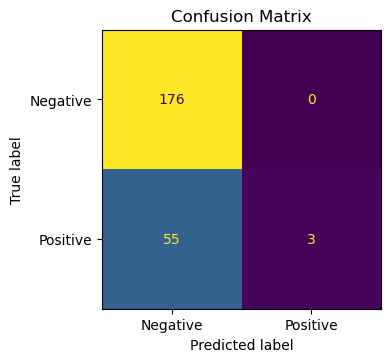

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
)

has_labels = predictions_df["true_label"].notna().any()

if has_labels:
    valid = predictions_df[predictions_df["true_label"].notna()].copy()
    y_true  = valid["true_label"].astype(int)
    y_pred  = valid["predicted_label"].astype(int)
    y_score = valid["prediction_score"].astype(float)

    print("=" * 50)
    print("CLASSIFICATION METRICS")
    print("=" * 50)
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC AUC   : {roc_auc_score(y_true, y_score):.4f}")
    print(f"PR AUC    : {average_precision_score(y_true, y_score):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("No true labels found — skipping evaluation.")

## 8. Top Hits

In [ ]:
top_hits = (
    predictions_df[predictions_df["predicted_label"] == 1]
    .sort_values("prediction_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

n_pos = (predictions_df["predicted_label"] == 1).sum()
print(f"Top 20 predicted positives (out of {n_pos} total predicted positives):")
top_hits[["sample_id", "smiles", "prediction_score", "true_label"]]

## 9. Save Hits Above Threshold

In [ ]:
SCORE_THRESHOLD = 0.7

hits_df = (
    predictions_df[predictions_df["prediction_score"] >= SCORE_THRESHOLD]
    .sort_values("prediction_score", ascending=False)
    .reset_index(drop=True)
)

hits_path = OUTPUT_PATH.replace(".csv", f"_hits_t{SCORE_THRESHOLD}.csv")
hits_df.to_csv(hits_path, index=False)

print(f"Hits with score >= {SCORE_THRESHOLD}: {len(hits_df)}")
print(f"Saved to: {hits_path}")
hits_df.head()